Este código implementa un flujo de inferencia en Google Colab que permite al usuario cargar una imagen de un dígito manuscrito y visualizar cómo es procesada antes de ser evaluada por una red neuronal previamente entrenada.

El procedimiento inicia con la carga manual de una imagen, la cual es transformada progresivamente mediante técnicas de preprocesamiento como conversión a escala de grises, inversión de colores y binarización, con el objetivo de estandarizarla al formato del dataset MNIST.
Posteriormente, la imagen es redimensionada a 28×28 píxeles y normalizada, replicando las condiciones bajo las cuales el modelo fue entrenado, lo que garantiza coherencia en la fase de predicción.

Un aporte clave del código es la visualización comparativa entre la imagen original y la versión procesada, permitiendo evidenciar cómo la red neuronal “interpreta” el dígito en términos de patrones de píxeles.
Finalmente, el modelo realiza la predicción del número y devuelve la clase más probable, basada en la salida probabilística generada por la capa softmax.

Sube una foto de un número del 0 al 9 (preferiblemente recortada en forma cuadrada):


Saving IMG_2106.jpeg to IMG_2106 (5).jpeg

Procesando archivo "IMG_2106 (5).jpeg"...


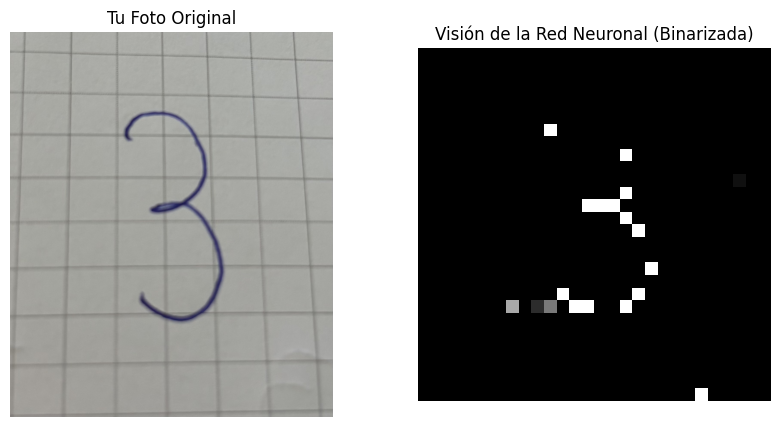

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

---> ¡La red neuronal dice que el número es: 3! <---


In [13]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("Sube una foto de un número del 0 al 9 (preferiblemente recortada en forma cuadrada):")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'\nProcesando archivo "{fn}"...')

    # --- NUEVO: Guardamos la imagen original a color ---
    # OpenCV lee las imágenes en formato BGR, así que la pasamos a RGB para que se vea normal
    img_original = cv2.imread(fn)
    img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    # 1. Leer la imagen en escala de grises para procesarla
    img = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)

    # 2. Invertir los colores (fondo negro, número blanco)
    img = cv2.bitwise_not(img)

    # 3. APLICAR UMBRAL (Elimina sombras y grises del fondo)
    _, img = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)

    # 4. Redimensionar a 28x28 píxeles
    img = cv2.resize(img, (28, 28))

    # --- NUEVO: Mostrar ambas imágenes lado a lado ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # Creamos espacio para 1 fila y 2 columnas

    # Gráfico 1: Imagen Original
    axes[0].imshow(img_original_rgb)
    axes[0].set_title("Tu Foto Original")
    axes[0].axis('off') # Quitamos las reglas de los ejes para que se vea más limpio

    # Gráfico 2: Visión de la Red
    axes[1].imshow(img, cmap='gray')
    axes[1].set_title("Visión de la Red Neuronal (Binarizada)")
    axes[1].axis('off')

    plt.show() # Mostramos todo junto

    # 5. Aplanar y normalizar (como en x_train)
    img_array = img.reshape((1, 28 * 28))
    img_array = img_array.astype('float32') / 255

    # 6. Predecir
    prediccion = model.predict(img_array)
    clase_predicha = np.argmax(prediccion)

    print(f"\n---> ¡La red neuronal dice que el número es: {clase_predicha}! <---")